<hr>
<center> Coding Exercise for Control Systems<br>
<b> Exercise 9: Loop Shaping Design </b> <br>
Prof. Dr. Florian Dörfler <br>
Automatic Control Laboratory, ETH Zurich </center>
<hr>

In this notebook, we will learn about designing controllers in the frequency domain based on loop shapes.

<blockquote>
<b>Activity:</b> Execute the code cells below so that the necessary libraries get imported.
</blockquote>

In [ ]:
!pip install control

In [22]:
import numpy as np # the standard library for numerics, vectors, matrices
import control as ct # the standard library for basic operations for analysis and design of feedback control systems
import matplotlib.pyplot as plt # a comprehensive library for creating static, animated, and interactive visualizations
import math

<b> C 9.1: Loop Shaping: Lead Compensator </b>

> **Activity:** Generate the Bode plot of the open-loop system $ G(s)=\frac{s+10}{s(s+1)} $.

In [29]:
# your code goes here

<blockquote>
<b>Solution:</b> You can check your answer with the solution by clicking on the "..." below.
</blockquote>

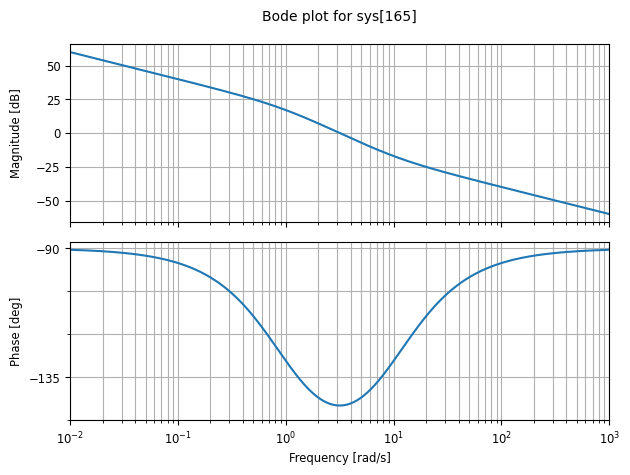

In [30]:
s = ct.tf('s')
G = (s+10) / (s * (s+1))
plt.figure()
ct.bode_plot(G, omega_limits=[1e-2, 1e3], dB=True)
plt.show()

> <b>Activity:</b> We aim to design a controller $K(s)$ satisfying $K(0)=5$ such that the slope of the Bode magnitude plot of $G(s)K(s)$ is $-60$ dB/decade for $\omega \geq 100$ rad/s. Find such a controller, generate the Bode plot of the transfer function $G(s)K(s)$, and obtain the gain and phase margins.

In [31]:
# your code goes here

<blockquote>
<b>Solution:</b> You can check your answer with the solution by clicking on the "..." below.
</blockquote>

The slope of the Bode plot of $G(s)$ is $-20$ dB/decade for $\omega \geq 10$ rad/s. To obtain a slope of $-60$ dB/decade, we need to have two additional LHP pole. We design the following controller $K(s) = 5/((1+s/100)^2)$.

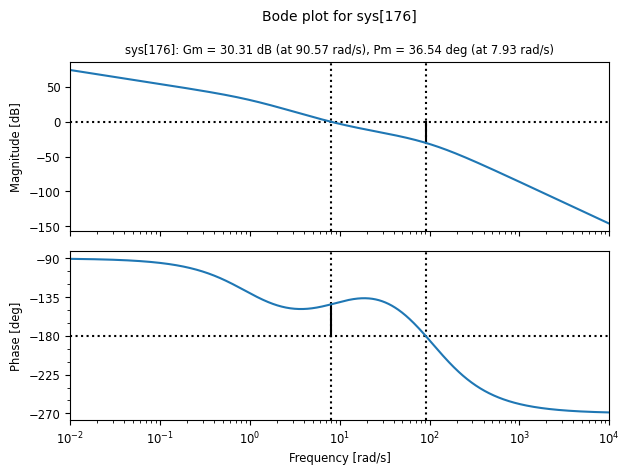

Gain margin: 32.77281128950792
Phase margin: 36.537160740508 deg
GM frequency: 90.56595311187131
PM frequency: 7.932444651283953


In [32]:
K = 5 / (1 + 0.01*s)**2
plt.figure()
ct.bode_plot(G * K, omega_limits=[1e-2, 1e4], dB=True, display_margins=True)
plt.show()

# Gain and phase margins
GM, PM, GM_frequency, PM_frequency = ct.margin(G * K)
print(f"Gain margin: {GM}\nPhase margin: {PM} deg")
print(f"GM frequency: {GM_frequency}\nPM frequency: {PM_frequency}")

> <b>Activity:</b> Design a lead compensator $C(s)$ such that the phase margin is at least $70^\circ$ and
the gain margin is at least $10$. Generate the Bode plot of the open-loop transfer function in iv).

In [33]:
# your code goes here

<blockquote>
<b>Solution:</b> You can check your answer with the solution by clicking on the "..." below.
</blockquote>

In [34]:
# implement lead compensation
PM_desired = 70  # desired phase margin in degrees
phi_max = PM_desired - PM + 5  # 5 is an additional margin
alpha = (1 - np.sin(math.radians(phi_max))) / (1 + np.sin(math.radians(phi_max)))

T = 1/(PM_frequency * math.sqrt(alpha))
C_lead = ct.tf([T,1], [alpha*T,1])
print(f'The lead compensator is {C_lead}')

The lead compensator is <TransferFunction>: sys[180]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.2611 s + 1
  -------------
  0.06086 s + 1


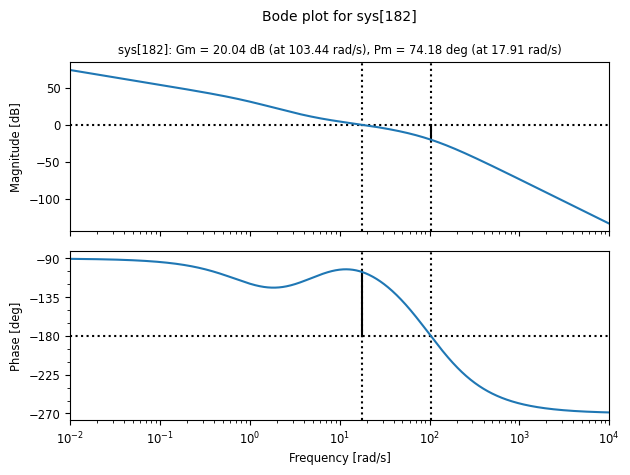

Gain margin: 10.051773785219302
Phase margin: 74.17524760018566 deg


In [35]:
L = G * K * C_lead
plt.figure()
ct.bode_plot(L, omega_limits=[1e-2, 1e4], dB=True, display_margins=True)
plt.show()

# Gain and phase margins
GM_lead, PM_lead, _, _ = ct.margin(L)
print(f"Gain margin: {GM_lead}\nPhase margin: {PM_lead} deg")

<b> C 9.2: Lead-Lag Compensator: Compare the Bode plots of the designs in i), ii), and iii). </b>

<blockquote>
<b>Activity:</b> Plot the Bode plots of the open-loop transfer functions.
</blockquote>

In [36]:
# your code goes here

<blockquote>
<b>Solution:</b> You can check your answer with the solution by clicking on the "..." below.
</blockquote>

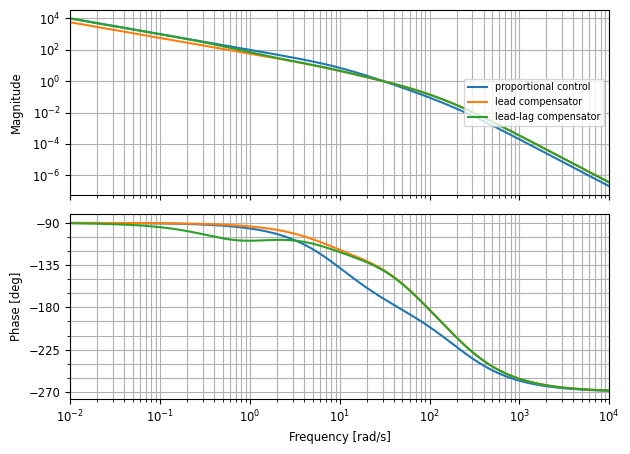

For the open-loop system with lead-lag compensator:
Gain margin: 6.326204428603968
Phase margin: 39.20896950557133 deg
GM frequency: 93.85139020474627
PM frequency: 30.616586185351117


In [37]:
s = ct.tf('s')
G = 1 / s / (1+s/10) / (1+s/200)
k = 100
K_lead = 0.57 * (0.057*s+1) / (0.325*0.057*s+1)
K_lag = 1.75 * (s+1) / (1.75*s+1)

sys_lead = K_lead * k * G
sys_lead_lag = K_lag * sys_lead

plt.figure()
ct.bode_plot(k*G, omega_limits=[1e-2, 1e4], label="proportional control")
ct.bode_plot(sys_lead, omega_limits=[1e-2, 1e4], label="lead compensator")
ct.bode_plot(sys_lead_lag, omega_limits=[1e-2, 1e4], label="lead-lag compensator")
plt.show()

# Gain and phase margins
GM, PM, GM_frequency, PM_frequency = ct.margin(sys_lead_lag)
print("For the open-loop system with lead-lag compensator:")
print(f"Gain margin: {GM}\nPhase margin: {PM} deg")
print(f"GM frequency: {GM_frequency}\nPM frequency: {PM_frequency}")

<blockquote>
<b>Activity:</b> Plot the response of the closed-loop system with the above lead-lag compensator given a unit ramp reference input.
</blockquote>

In [38]:
# your code goes here

<blockquote>
<b>Solution:</b> You can check your answer with the solution by clicking on the "..." below.
</blockquote>

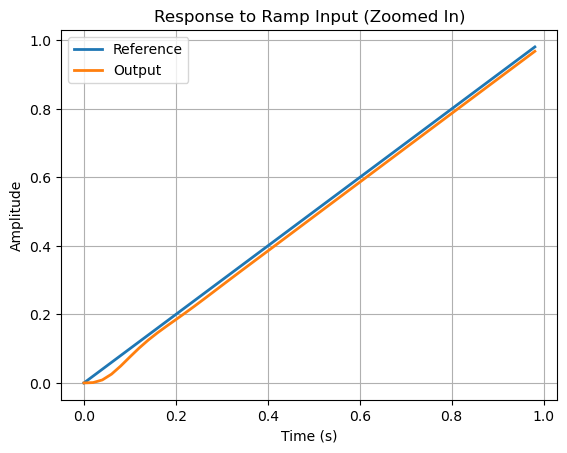

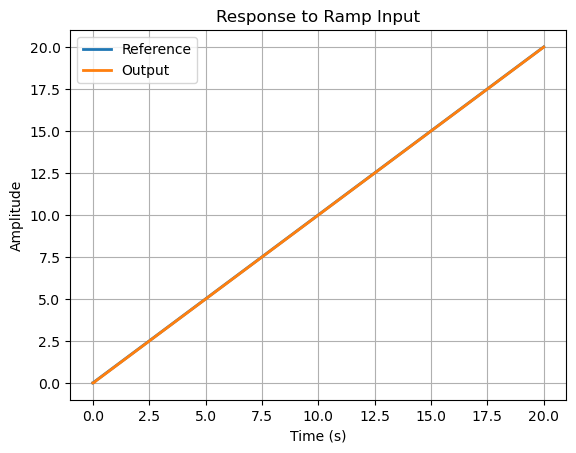

The steady-state error for a ramp input is approximately 0.0100


In [39]:
# Plot the response given a ramp reference input
sys_CL = ct.feedback(sys_lead_lag, 1)
T_quad = np.linspace(0, 20, 1000)
U_quad = T_quad

t_quad, y_quad = ct.forced_response(sys_CL, T=T_quad, U=U_quad)
plt.figure(1)
plt.plot(T_quad[0: 50], U_quad[0: 50], linewidth=2)
plt.plot(t_quad[0: 50], y_quad[0: 50], linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend(['Reference', 'Output'])
plt.title('Response to Ramp Input (Zoomed In)')
plt.grid(True)
plt.show()

plt.figure(2)
plt.plot(T_quad, U_quad, linewidth=2)
plt.plot(t_quad, y_quad, linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend(['Reference', 'Output'])
plt.title('Response to Ramp Input')
plt.grid(True)
plt.show()

print(f"The steady-state error for a ramp input is approximately {abs(U_quad[-1] - y_quad[-1]):.4f}")

<b> C 9.3: Open and closed loop shapes </b>

Consider a plant $G(s) = \frac{5(s-4)}{(s+1)(s+7)}$ and a controller $K(s) = -\frac{0.5s+1}{2s(0.1s+1)}$ in a closed-loop setting, as shown in the figure below. 

Check if the system $G(s)K(s)$ has the following properties:

1. cross over frequency $\omega_c > 1$ rad/sec, and
2. phase margin $PM>40^\circ$.

![control_loop.jpg](attachment:1ad3203a-2a78-4271-a4a8-7908dc5db63c.jpg)

<blockquote>
<b>Activity:</b> Plot the Bode plot of the open-loop transfer function and the step response of the system. Answer the above questions.
</blockquote>

In [ ]:
# your code goes here

<blockquote>
<b>Solution:</b> You can check your answer with the solution by clicking on the "..." below.
</blockquote>

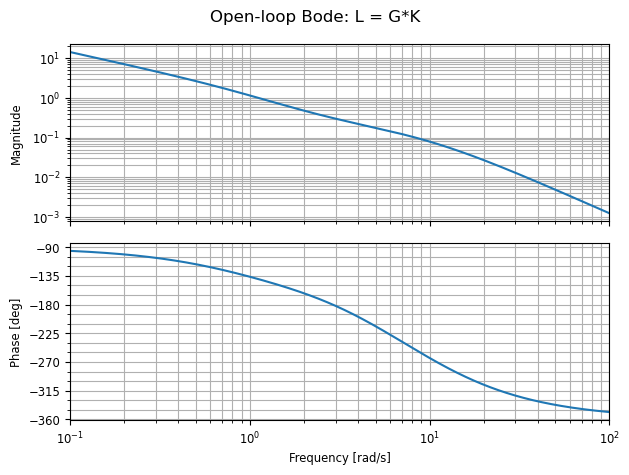

Gain margin: 3.213691967859066
Phase margin: 40.0950409307259 deg
GM frequency: 2.8900432445483957
PM frequency: 1.1131700112982044


In [ ]:
s = ct.tf('s')
G = 5*(s - 4)/((s + 1)*(s + 7))
K = -0.5 * (s/2 + 1) / (s * (s/10 + 1))
L = G * K

# Bode plot of the open-loop L
plt.figure()
ct.bode_plot(L, omega_limits=[0.1, 100])
plt.suptitle('Open-loop Bode: L = G*K')
plt.show()

# Gain and phase margins
GM, PM, GM_frequency, PM_frequency = ct.margin(L)
print(f"Gain margin: {GM}\nPhase margin: {PM} deg")
print(f"GM frequency: {GM_frequency}\nPM frequency: {PM_frequency}")

From the Bode plot, we know:
1. The crossover frequency is $1.113$ rad/s and is larger than $1$ rad/s;
2. The phase margin is $40.095^\circ$ and is larger than $40^\circ$.

> **Activity**: Generate the Bode plots of the sensitivity function $S$ and the complementary sensitivity function $T$.

In [ ]:
# your code goes here

<blockquote>
<b>Solution:</b> You can check your answer with the solution by clicking on the "..." below.
</blockquote>

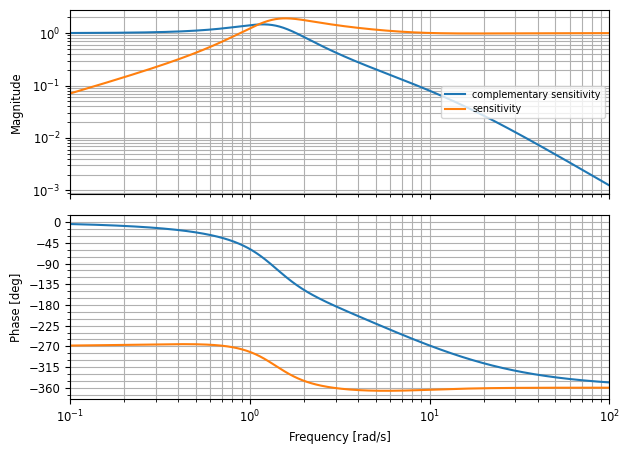

In [ ]:
# Closed-loop transfer functions
T = ct.feedback(L, 1)   # complementary sensitivity (closed-loop from reference to output)
S = ct.feedback(1, L)   # sensitivity

# Bode plots of complementary sensitivity (T) and sensitivity (S)
plt.figure()
ct.bode_plot(T, omega_limits=[0.1, 100], label='complementary sensitivity')
ct.bode_plot(S, omega_limits=[0.1, 100], label='sensitivity')
plt.show()

> **Activity**: For a reference step with amplitude one, check if the closed-loop system has:

1. zero steady-state error,
2. input: $|u(t)|< 1 , \forall\; t$, and 
3. output: $|y(t)|< 1.5 , \forall\; t$.

In [ ]:
# your code goes here

<blockquote>
<b>Solution:</b> You can check your answer with the solution by clicking on the "..." below.
</blockquote>

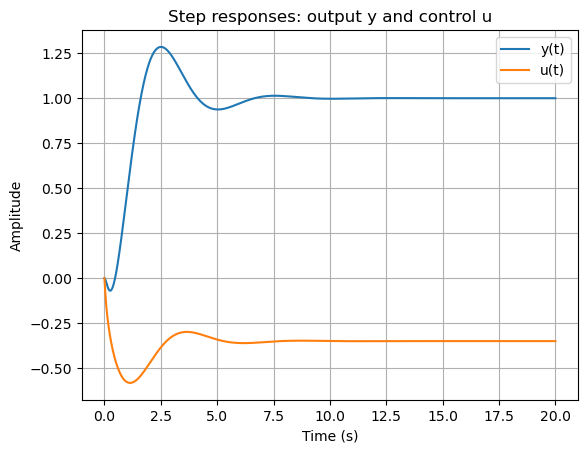

In [ ]:
# Step responses: output y = T*ref and control input u = K*S*ref
t_y, y = ct.step_response(T, T=20)
t_u, u = ct.step_response(K * S, T=20)

plt.figure()
plt.plot(t_y, y, label='y(t)')
plt.plot(t_u, u, label='u(t)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.title('Step responses: output y and control u')
plt.show()

From the step response, we know:
1. The steady-state error is zero.
2. The input satisfies $|u(t)|< 1 , \forall t$.
3. The output satisfies $|y(t)|< 1.5 , \forall t$.